In [1]:
from autograd import jacobian
import autograd.numpy as anp

In [2]:
timesteps = 100
dt = 0.1

In [3]:
def f(state, theta):
    x, y = state
    alpha, beta, gamma, delta = theta
    dx = (alpha * x) - (beta * x * y)
    dy = (delta * x * y) - (gamma * y)
    return anp.array([dx, dy])


In [4]:
def rk4_step(state, theta):
    k1 = f(state, theta)
    k2 = f(state + 0.5 * dt * k1, theta)
    k3 = f(state + 0.5 * dt * k2, theta)
    k4 = f(state + dt * k3, theta)

    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


def solver(theta):
    state = anp.array([10.0, 1.0])
    states = [state]

    for _ in range(timesteps):
        state = rk4_step(state, theta)
        states.append(state)

    return states

In [5]:
true_theta = [1.5, 1.0, 3.0, 1.0]

results = solver(true_theta)
true_states = anp.array(results) 


In [6]:
df_dstate = jacobian(rk4_step, 0)
df_dtheta = jacobian(rk4_step, 1)


In [7]:

def adjoint_grad(theta):
    states = solver(theta)
    states = anp.array(states)
    m = len(states)

    # this is MSE loss dL/dy
    #s = anp.zeros(2)
    s = 2 * (states[-1] - true_states[-1]) / m

    # loss for all 4 parameters
    L = anp.zeros_like(theta)

    for i in range(m - 1, 0, -1):
        state = states[i - 1]

        #s += 2 * (states[i] - true_states[i]) / m

        J_state = df_dstate(state, theta)
        J_theta = df_dtheta(state, theta)

        L += anp.dot(s, J_theta)
        s = anp.dot(s, J_state)

    return L

In [8]:
# Adam
m_adam = anp.zeros(4)
v_adam = anp.zeros(4)
beta1, beta2, eps = 0.9, 0.999, 1e-8
lr = 0.01
epochs = 2000

theta = anp.array([1.0, 0.5, 2.5, 0.5])


from tqdm import tqdm
for i in tqdm(range(epochs)):
    g = adjoint_grad(theta)
    
    m_adam = beta1 * m_adam + (1 - beta1) * g
    v_adam = beta2 * v_adam + (1 - beta2) * g**2
    m_hat = m_adam / (1 - beta1**(i+1))
    v_hat = v_adam / (1 - beta2**(i+1))
    
    theta = theta - lr * m_hat / (anp.sqrt(v_hat) + eps)
    
    if i % 100 == 0:
        states = anp.array(solver(theta))
        loss = anp.mean((states - true_states)**2)
        print(f"gradient norm -> {anp.linalg.norm(g)} loss -> {loss}")

  0%|          | 1/2000 [00:00<12:55,  2.58it/s]

gradient norm -> 5.3126490562239015 loss -> 16.45049844975795


  5%|▌         | 101/2000 [00:36<11:16,  2.81it/s]

gradient norm -> 0.05246716673182859 loss -> 5.632769034945474


 10%|█         | 201/2000 [01:12<11:44,  2.55it/s]

...

 90%|█████████ | 1801/2000 [10:35<01:11,  2.80it/s]

gradient norm -> 0.0006291838600271636 loss -> 0.16396877824859382


 95%|█████████▌| 1901/2000 [11:11<00:36,  2.75it/s]

gradient norm -> 0.0005594731866103745 loss -> 0.1352406603243138


100%|██████████| 2000/2000 [11:47<00:00,  2.83it/s]


In [9]:
# from tqdm import tqdm

# theta = anp.array([1.0, 0.7, 2.5, 0.7])
# learning_rate = 0.1
# epochs = 500

# for i in tqdm(range(epochs)):
#     g = adjoint_grad(theta)
#     theta = theta - learning_rate * g
#     if i % 50 == 0:
#         states = anp.array(solver(theta))
#         loss = anp.mean((states - true_states)**2)
#         print("gradient norm -> ", anp.linalg.norm(g))
#         print("loss -> ", loss)

In [10]:
theta

array([1.49695029, 0.93329875, 2.84991906, 0.90949937])

In [11]:
true_theta

[1.5, 1.0, 3.0, 1.0]

In [12]:
predictions = solver(theta)
predictions = anp.array(predictions)

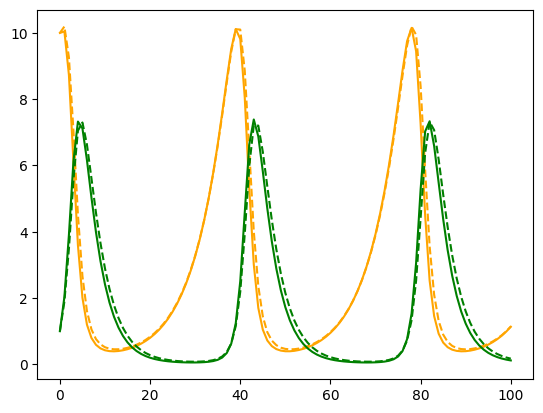

In [13]:
import matplotlib.pyplot as plt

plt.plot(true_states[:, 0], "orange")
plt.plot(predictions[:, 0], "orange", linestyle="--")
plt.plot(true_states[:, 1], "green")
plt.plot(predictions[:, 1],  "green", linestyle="--")
plt.show()